In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [76]:
ude_dir = {'Hunziker': 'code/experiments/ude_hunziker2010_uncertainty_2026-01-20_181050',
           'Konrath': 'code/experiments/ude_konrath2020_uncertainty_2026-01-20_100950'}

ode_dir = {'Hunziker': 'code/experiments/ode_hunziker2010_uncertainty_2026-01-19_132644',
           'Konrath': 'code/experiments/ode_konrath2020_uncertainty_2026-01-20_142837'}

In [81]:
import os
import glob
import pandas as pd
import numpy as np

def parse_training_log(file_path):
    losses = []
    with open(file_path, 'r') as f:
        for line in f:
            if "Average Epoch Loss =" in line:
                try:
                    loss_part = line.split("Average Epoch Loss =")[1].strip()
                    losses.append(float(loss_part))
                except ValueError:
                    continue
    return losses

def plot_loss_function(experiment_dirs, title_prefix=""):

    fig, ax = plt.subplots(figsize=(6, 4))
    
    for model_name, folder_path in experiment_dirs.items():
        
        # Adjust path to find where logic is running from
        # Assuming we are in code/utils/plotter, go up to code/ then use path
        search_paths = [
            os.path.join("../../", folder_path),
            folder_path,
            os.path.join("../../../", folder_path)
        ]
        
        full_path = None
        for p in search_paths:
            if os.path.exists(p):
                full_path = p
                break
        
        if not full_path:
            print(f"Could not find path for {model_name}: {folder_path}")
            continue

        all_losses = []
        seed_folders = glob.glob(os.path.join(full_path, "run_seed_*"))
        
        for seed_folder in sorted(seed_folders):
            log_file = os.path.join(seed_folder, "training_log.txt")
            if os.path.exists(log_file):
                losses = parse_training_log(log_file)
                all_losses.append(losses)
            
        min_len = min(len(l) for l in all_losses)
        all_losses_trunc = [l[:min_len] for l in all_losses]
        data = np.array(all_losses_trunc)
        
        mean_loss = np.mean(data, axis=0)
        lower_loss = np.percentile(data, 5, axis=0)
        upper_loss = np.percentile(data, 95, axis=0)
        epochs = np.arange(1, min_len + 1)
        
        ax.plot(epochs, mean_loss, label=model_name,
                lw=1)
        ax.fill_between(epochs, lower_loss, upper_loss, alpha=0.3)

        ax.set(xlim=(100,3000), ylim=(100, 2000),
               xlabel="Epoch", ylabel="Training Loss",
               xscale='log', yscale='log',
               xticks=(1, 10, 100, 1000),
               yticks=(100, 1000))
        ax.legend(loc='lower left',
                  title=f'{title_prefix} Model')
        ax.grid(True, which="both", ls="-", alpha=0.2)

        
    plt.tight_layout()
    plt.show()

Plotting UDE Loss:


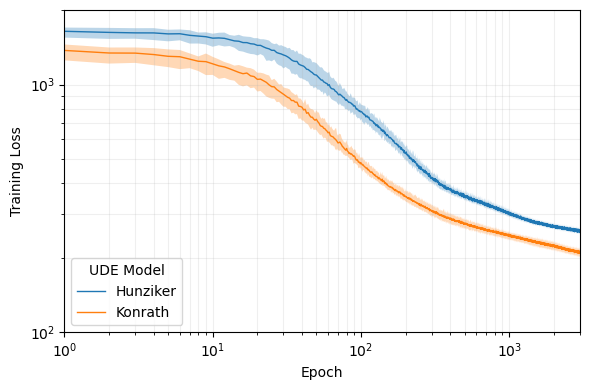


Plotting ODE Loss:


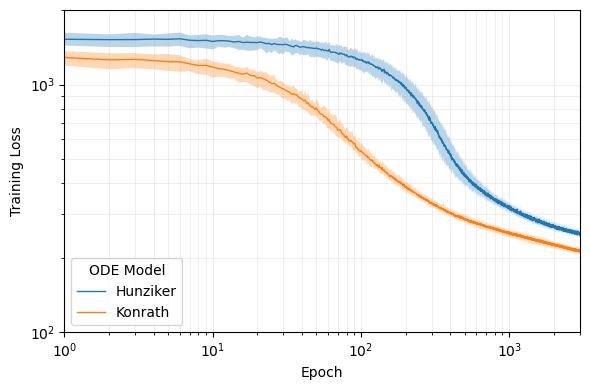

In [82]:
print("Plotting UDE Loss:")
plot_loss_function(ude_dir, "UDE")

print("\nPlotting ODE Loss:")
plot_loss_function(ode_dir, "ODE")

In [68]:
def plot_relative_rmse(experiment_dirs, title_prefix=""):
    fig, axes = plt.subplots(1, len(experiment_dirs), figsize=(12, 5))
    if len(experiment_dirs) == 1:
        axes = [axes]
    
    for ax, (model_name, folder_path) in zip(axes, experiment_dirs.items()):
        full_path = resolve_full_path(folder_path)
        if not full_path:
             print(f"Could not find path for {model_name}: {folder_path}")
             continue
        
        # Determine time points from config
        config_path = os.path.join(full_path, "config.json")
        if not os.path.exists(config_path):
             # Try inside a run folder
             seed_folders = glob.glob(os.path.join(full_path, "run_seed_*"))
             if seed_folders:
                 config_path = os.path.join(seed_folders[0], "config.json")
        
        if os.path.exists(config_path):
            with open(config_path, 'r') as f:
                config = json.load(f)
            time_start = config.get("time_start", 0)
            time_end = config.get("time_end", 20)
            time_step = config.get("time_step", 0.1)
            # Create time points array
            # Note: np.arange might exclude the end point if not careful, 
            # typical logic matches whatever was used in simulation
            time_points = np.arange(time_start, time_end + time_step, time_step)
        else:
            print(f"Config not found for {model_name}, skipping time axis setup.")
            time_points = None

        all_rrmse = []
        seed_folders = glob.glob(os.path.join(full_path, "run_seed_*"))
        
        for seed_folder in sorted(seed_folders):
            rrmse_file = os.path.join(seed_folder, "rmse_per_timepoint.txt")
            if os.path.exists(rrmse_file):
                try:
                    rrmse = np.loadtxt(rrmse_file)
                    all_rrmse.append(rrmse)
                except Exception as e:
                    print(f"Error loading {rrmse_file}: {e}")
        
        if not all_rrmse:
            print(f"No RRMSE data found for {model_name}")
            continue
            
        # Ensure all rows have same length
        min_len = min(len(r) for r in all_rrmse)
        all_rrmse_trunc = [r[:min_len] for r in all_rrmse]
        data = np.array(all_rrmse_trunc)
        
        # Adjust time_points if length mismatch
        if time_points is not None:
            if len(time_points) > min_len:
                time_points = time_points[:min_len]
            elif len(time_points) < min_len:
                # Fallback purely index-based
                time_points = np.arange(min_len)
        else:
             time_points = np.arange(min_len)
        
        mean_rrmse = np.mean(data, axis=0)
        lower = np.percentile(data, 25, axis=0)
        upper = np.percentile(data, 75, axis=0)
        
        ax.plot(time_points, mean_rrmse, label='Mean RRMSE')
        ax.fill_between(time_points, lower, upper, alpha=0.3, label='IQR')
        
        ax.set_title(f"{title_prefix} RRMSE - {model_name}")
        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Relative RMSE")
        ax.set_ylim(bottom=0, top=1) # As per example code, capped at 1 for clarity
        ax.legend()
        ax.grid(True, which="both", ls="-", alpha=0.2)
        
    plt.tight_layout()
    plt.show()

Plotting UDE Relative RMSE:


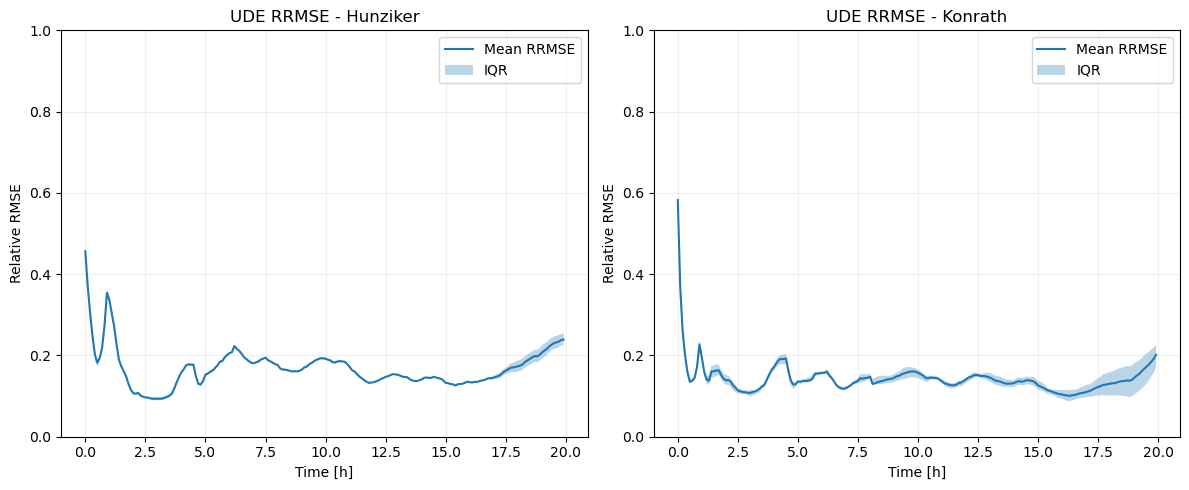


Plotting ODE Relative RMSE:


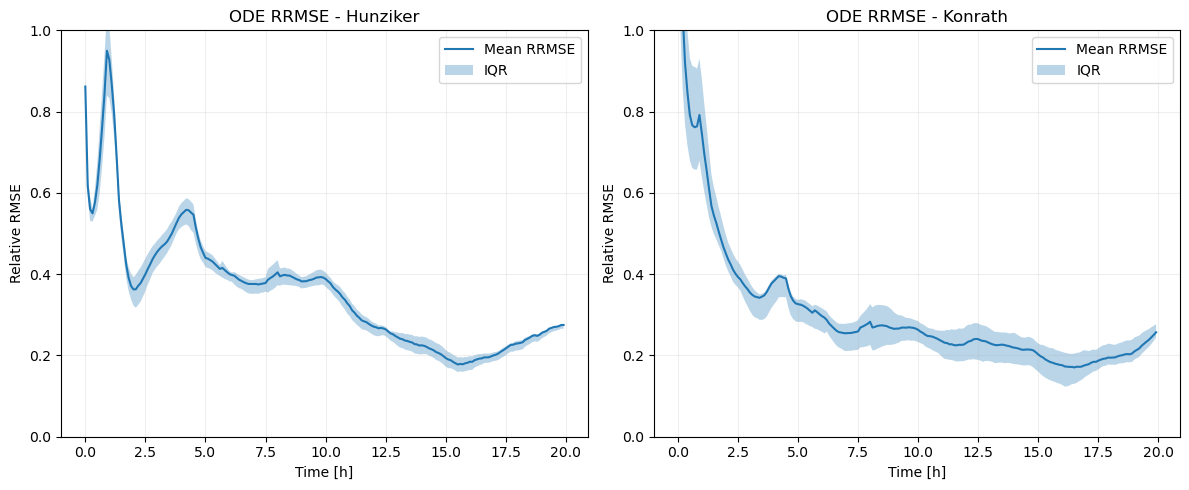

In [74]:
print("Plotting UDE Relative RMSE:")
plot_relative_rmse(ude_dir, "UDE")

print("\nPlotting ODE Relative RMSE:")
plot_relative_rmse(ode_dir, "ODE")